# Task 1 — Data Loading & Exploration

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

### Load Dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
# Shape
print("Rows and Columns :",df.shape)

# Information
df.info()

Rows and Columns : (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 

### Target Column

In [4]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


### Attrition Rate

In [5]:
attrition_rate = (df["Attrition"].value_counts(normalize=True))*100
print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


### Numeric & Categorical Columns

In [6]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numeric Columns :",len(numeric_cols))

print("Categorical Columns :",len(categorical_cols))

Numeric Columns : 26
Categorical Columns : 9


### Observation:-

The dataset is imbalanced because the number of employees who stayed is much higher than the number of employees who left the company. This imbalance should be considered while training machine learning models.

# Task 2 — Data Cleaning & Preprocessing

### Check for Missing/Null Values and Handle Them

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Drop Columns that Add No Value to Prediction

In [8]:
df.drop(
    columns=[
        'EmployeeNumber',
        'EmployeeCount',
        'Over18',
        'StandardHours'
    ],
    inplace=True
)

### Convert the Target Column (Attrition) from Yes/No to 1/0

In [9]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

### Encode all Remaining Categorical Columns using One-Hot Encoding

In [10]:
df = pd.get_dummies(df, drop_first=True)
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,41,4,2,4,...,True,False,False,False,False,False,False,True,False,False
1466,39,0,613,6,1,4,42,2,3,1,...,False,False,False,False,False,False,False,True,False,False
1467,27,0,155,4,3,2,87,4,2,2,...,False,False,True,False,False,False,False,True,False,True
1468,49,0,1023,2,3,4,63,2,2,2,...,False,False,False,False,False,True,False,True,False,False


### Scale Numeric Features using StandardScaler

In [11]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

scaler = StandardScaler()

X = scaler.fit_transform(X)

### Final Verification

In [12]:
print(df.isnull().sum().sum())
print(df.duplicated().sum())

0
0


# Task 3 — Exploratory Data Analysis (EDA)

### Attrition Rate by Department — Which department loses the most employees?

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64


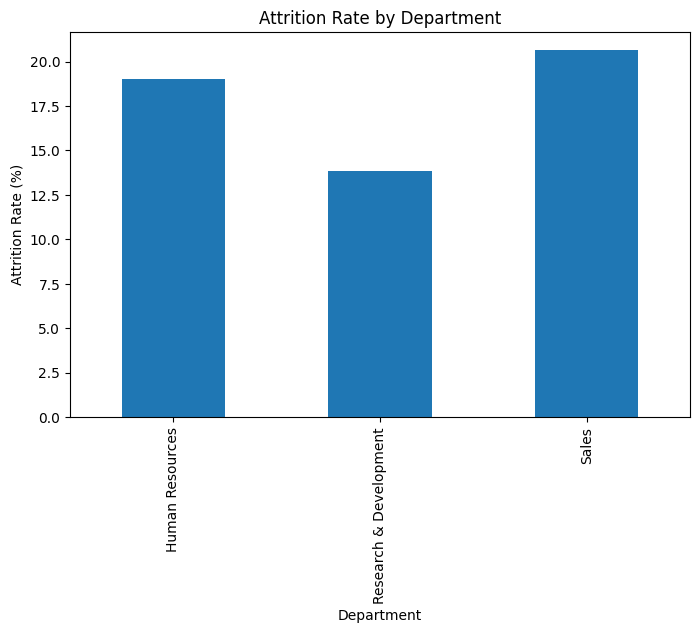

In [13]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

department_attrition = df.groupby("Department")["Attrition"].mean() * 100

print(department_attrition)

plt.figure(figsize=(8,5))

department_attrition.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.savefig("charts/department_attrition.png")

plt.show()

### Attrition Rate by Job Role — Which roles have the highest exit rate?

JobRole
Healthcare Representative     6.870229
Human Resources              23.076923
Laboratory Technician        23.938224
Manager                       4.901961
Manufacturing Director        6.896552
Research Director             2.500000
Research Scientist           16.095890
Sales Executive              17.484663
Sales Representative         39.759036
Name: Attrition, dtype: float64


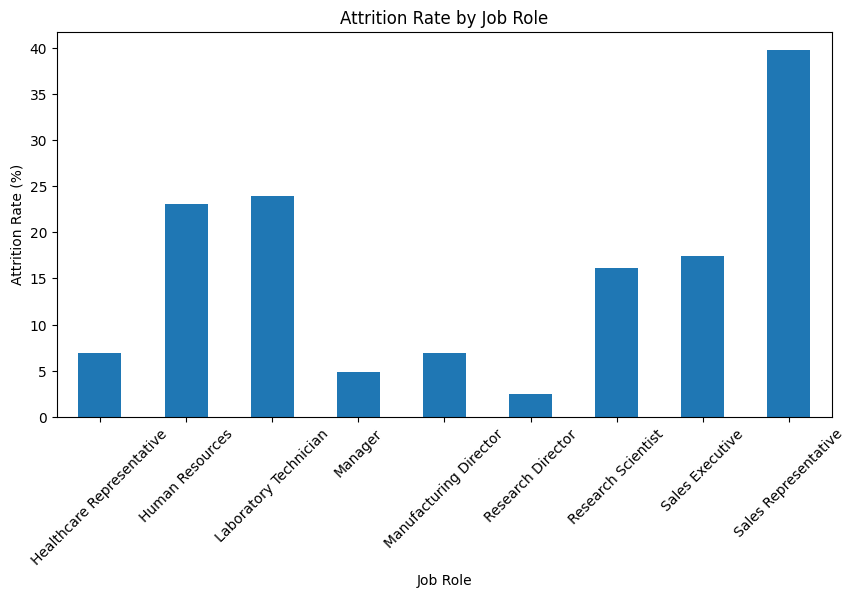

In [14]:
jobrole_attrition = df.groupby("JobRole")["Attrition"].mean() * 100

print(jobrole_attrition)

plt.figure(figsize=(10,5))

jobrole_attrition.plot(kind="bar")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45)

plt.savefig("charts/jobrole_attrition.png")

plt.show()

### Attrition vs Monthly Income — Do lower paid employees leave more?

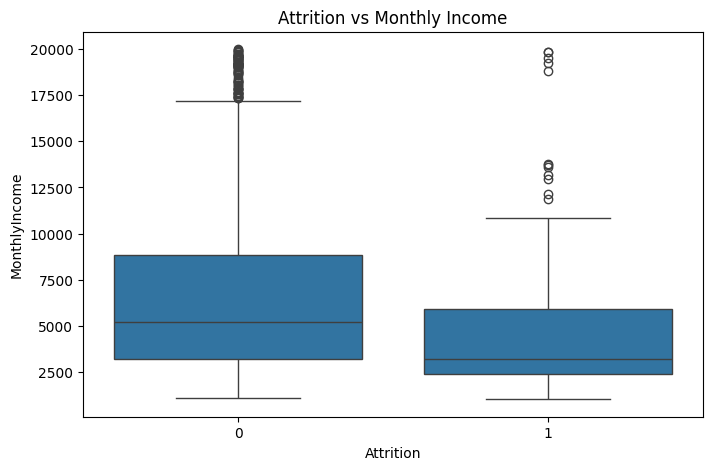

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

plt.title("Attrition vs Monthly Income")

plt.savefig("charts/monthly_income_attrition.png")

plt.show()

### Attrition vs Work-Life Balance Rating — Is there a visible pattern?

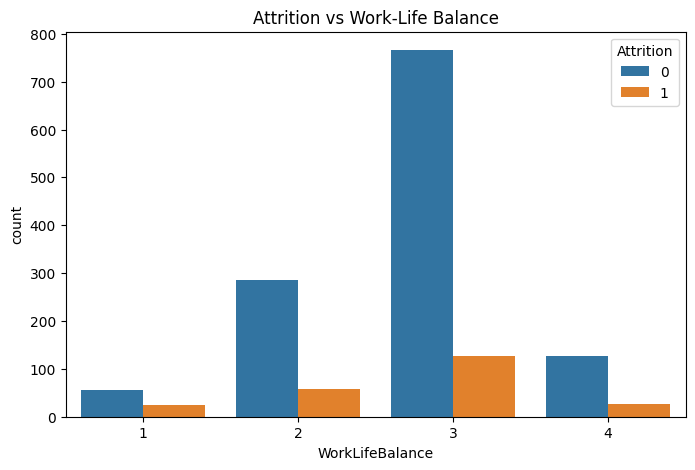

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df)

plt.title("Attrition vs Work-Life Balance")

plt.savefig("charts/worklifebalance_attrition.png")

plt.show()

### Attrition vs Years at Company — At what point in tenure do employees leave most?

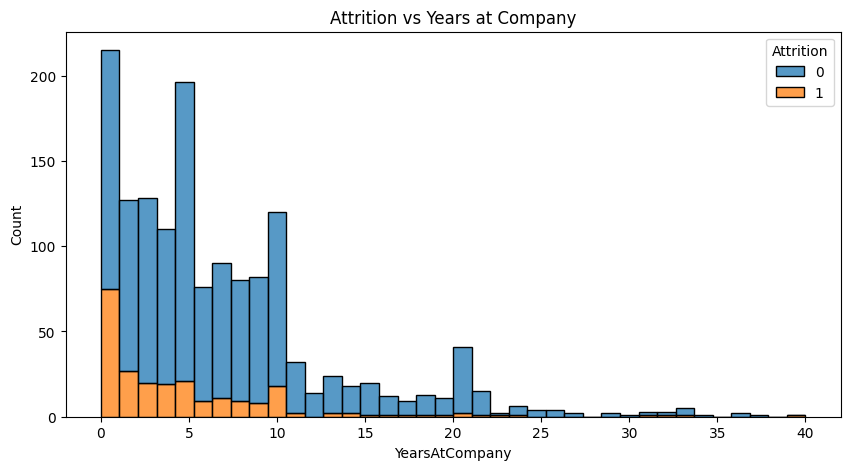

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack"
)

plt.title("Attrition vs Years at Company")

plt.savefig("charts/years_at_company_attrition.png")

plt.show()

### Write 4–5 Specific Business Insights

1. The Sales department has the highest attrition rate (20.63%), followed by Human Resources (19.05%). The Research & Development department has the lowest attrition rate (13.84%).

2. Among all job roles, Sales Representatives have the highest attrition rate (39.76%), indicating that employees in this role leave the company much more frequently than others.

3. Laboratory Technicians (23.94%) and Human Resources employees (23.08%) also show relatively high attrition rates and should be monitored by the HR team.

4. Managers (4.90%) and Research Directors (2.50%) have the lowest attrition rates, suggesting better employee retention in senior-level positions.

5. The EDA indicates that employee attrition is not evenly distributed across departments and job roles. HR should focus retention strategies on high-risk departments and roles, especially Sales Representatives.

# Task 4 — Model Building & Comparison

### Split Data into Training and Test Sets (80/20)

In [18]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Drop unnecessary columns
df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

# Convert target column
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [19]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

Attrition
0    986
1    190
Name: count, dtype: int64
Attrition
0    247
1     47
Name: count, dtype: int64


### Train Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

### Train Random Forest Classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

### Train Gradient Boosting Classifier

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_prob = gb.predict_proba(X_test)[:,1]

### Record all Results in a Comparison Table

In [29]:
comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1-Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

comparison_table

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.375000,0.063830,0.109091,0.751917
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


# Task 5 — Model Evaluation

### Evaluate all 3 models using Confusion Matrix

In [32]:
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(y_test, lr_pred)
rf_cm = confusion_matrix(y_test, rf_pred)
gb_cm = confusion_matrix(y_test, gb_pred)

print("Logistic Regression")
print(lr_cm)

print("\nRandom Forest")
print(rf_cm)

print("\nGradient Boosting")
print(gb_cm)

Logistic Regression
[[191  56]
 [ 18  29]]

Random Forest
[[242   5]
 [ 44   3]]

Gradient Boosting
[[240   7]
 [ 37  10]]


### Identify and Clearly State Which Model Performed Best and Why

Model	           ROC-AUC
Logistic Regression	 0.7986 ✅
Gradient Boosting	0.7941
Random Forest	0.7519






Reason: Logistic Regression achieved the highest ROC-AUC score (0.7986) and the highest recall among the three models, making it the most effective model for identifying employees who are likely to leave the company.

### Extract Feature Importance for the Best Model

In [34]:
feature_importance = pd.DataFrame({
    "Feature": df.drop("Attrition", axis=1).columns,
    "Importance": abs(lr.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


### Rank the Top 10 Most Important Features

In [35]:
top10 = feature_importance.head(10)

top10

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


# Task 6 — Visualization

### Confusion Matrix Heatmap for your Best Model

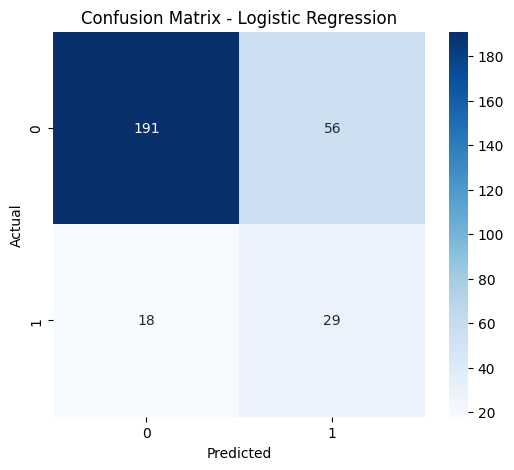

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/confusion_matrix.png")

plt.show()

### Horizontal Bar Chart of Top 10 Feature Importances

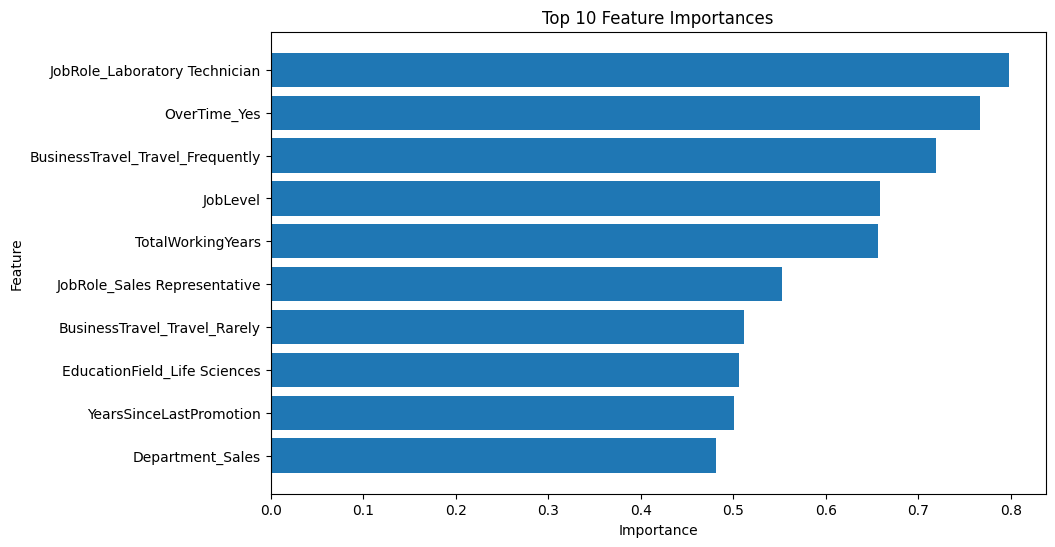

In [37]:
plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.savefig("charts/top10_feature_importance.png")

plt.show()

### ROC Curve Comparing all 3 Models

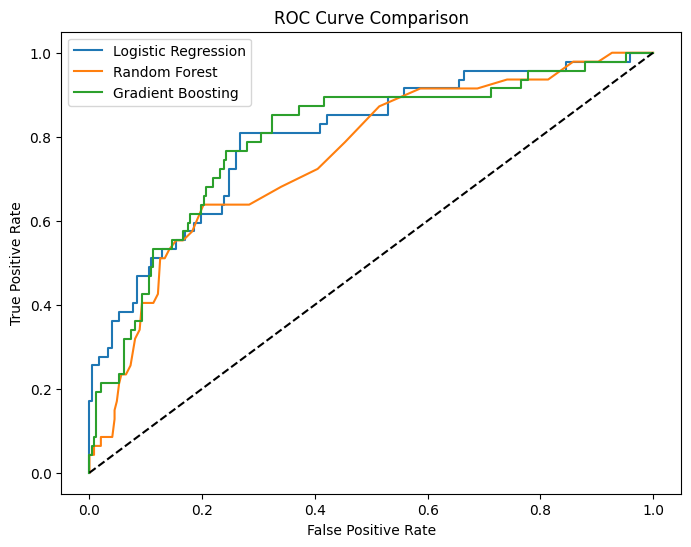

In [38]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig("charts/roc_curve.png")

plt.show()